# Song Popularity Prediction

In this notebook, based on the results of the data analysis we will do feature engineering and preprocess the data for next steps that is model creation and evaluation<br><br>

**1. Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer


**2. Loading the dataset**

In [2]:
df = pd.read_csv('../data/raw/spotify_tracks.csv')
df.sample(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
38663,38663,7wBMSC2iKZovFk0IjcVIEy,Deerhunter,Microcastle,Agoraphobia,48,202640,False,0.579,0.942,...,-6.880,1,0.0354,0.03030,0.820000,0.6550,0.394,120.059,4,garage
10987,10987,49eiytWhbfWqYJDvJ8cGMX,The Future Sound Of London,Accelerator Deluxe,Papua New Guinea (Blue States Full Length Mix),11,347533,False,0.586,0.771,...,-7.441,0,0.0344,0.04790,0.915000,0.2710,0.625,99.987,4,breakbeat
20185,20185,69C7u1nZcyZmuZXNNF5U9C,Lady Gaga,Beginner Ride (Mixtape Vol. 1),Born This Way,0,260413,False,0.586,0.835,...,-5.117,1,0.1460,0.00387,0.000000,0.3040,0.492,123.936,4,dance
18847,18847,1rzsJZGhqKvGEbS5SnOZoc,Kathleen Madigan,Bothering Jesus,Sarah Mclachlan / Sad Animals,21,195210,False,0.522,0.820,...,-6.788,1,0.4510,0.77600,0.000000,0.9550,0.484,87.523,4,comedy
100340,100340,0AUoTRhsCMqttmptWWWDmn,Royal Club,Su Majestad,Su Majestad,37,348760,False,0.321,0.932,...,-1.037,0,0.1880,0.00254,0.000031,0.0842,0.271,198.082,4,ska


**3. Feature Engineering** 

We will be creating new Features based on our understanding of the data : <br>
* party score  = energy x dancebility
* happy dance = valence x dancebility
* mood = valence * energy
* instrulentalness --> yes or no
* tempo --> low medium high
<br><br>
For features like artists, since for a particular track there could be n number of artists involved hence we create some new features using that: <br>

* num artists = calculate the number of artists involved in a particular track
* is collab = indicates if more than one artist is involved or not
* artist popularity mean = mean popularity of all the artists involved

In [3]:
df["party_score"] = df["danceability"] * df["energy"] 
df["happy_dance"] = df["danceability"] * df["valence"] 
df["mood_score"]  = (df["valence"] * df["energy"] )/2

df["is_instrumental"] = (df["instrumentalness"] > 0.5).astype(int)

artist_freq = df['artists'].value_counts()
df['artist_freq'] = df['artists'].map(artist_freq)

artist_mean = df.groupby('artists')['popularity'].mean()
df['artist_popularity_mean'] = df['artists'].map(artist_mean)

df['num_artists'] = df['artists'].apply(
    lambda x: len(x.split(',')) if isinstance(x, str) else 0
)

df['is_collab'] = df['num_artists'].apply(lambda x: 1 if x > 1 else 0)

**4. Dropping unnecessary columns**

In [4]:
df.drop(columns=['Unnamed: 0','track_id', 'track_name'], inplace=True)

**8. Handling missing values**

In [5]:
df.isna().sum()

artists                   1
album_name                1
popularity                0
duration_ms               0
explicit                  0
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
time_signature            0
track_genre               0
party_score               0
happy_dance               0
mood_score                0
is_instrumental           0
artist_freq               1
artist_popularity_mean    1
num_artists               0
is_collab                 0
dtype: int64

Since only four features have one missing value hence we will directly drop the values

In [6]:
df.dropna(inplace=True)

**5. Transforming columns**

In [7]:
skew_col = []

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    skew_val = df[col].skew()
    if skew_val > 0.4 or skew_val < -0.4:
        skew_col.append(col)

print('Skewed Columns:', skew_col)

Skewed Columns: ['duration_ms', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'time_signature', 'happy_dance', 'mood_score', 'artist_freq', 'num_artists', 'is_collab']


Removing "mode" and "time_signature" as although they have numerical values but they are categorical in nature<br>
Applying **"yeo-johnson"** transformation on the columns as it can be applied on both positive and negative skewness

In [8]:
skew_col.remove('mode')
skew_col.remove('time_signature')

transformer = PowerTransformer(method='yeo-johnson')
for col in skew_col:
    df[col] = transformer.fit_transform(df[col].values.reshape(-1, 1))

Now plotting the columns to see if the columns are transformed i.e skewness is removed or not 

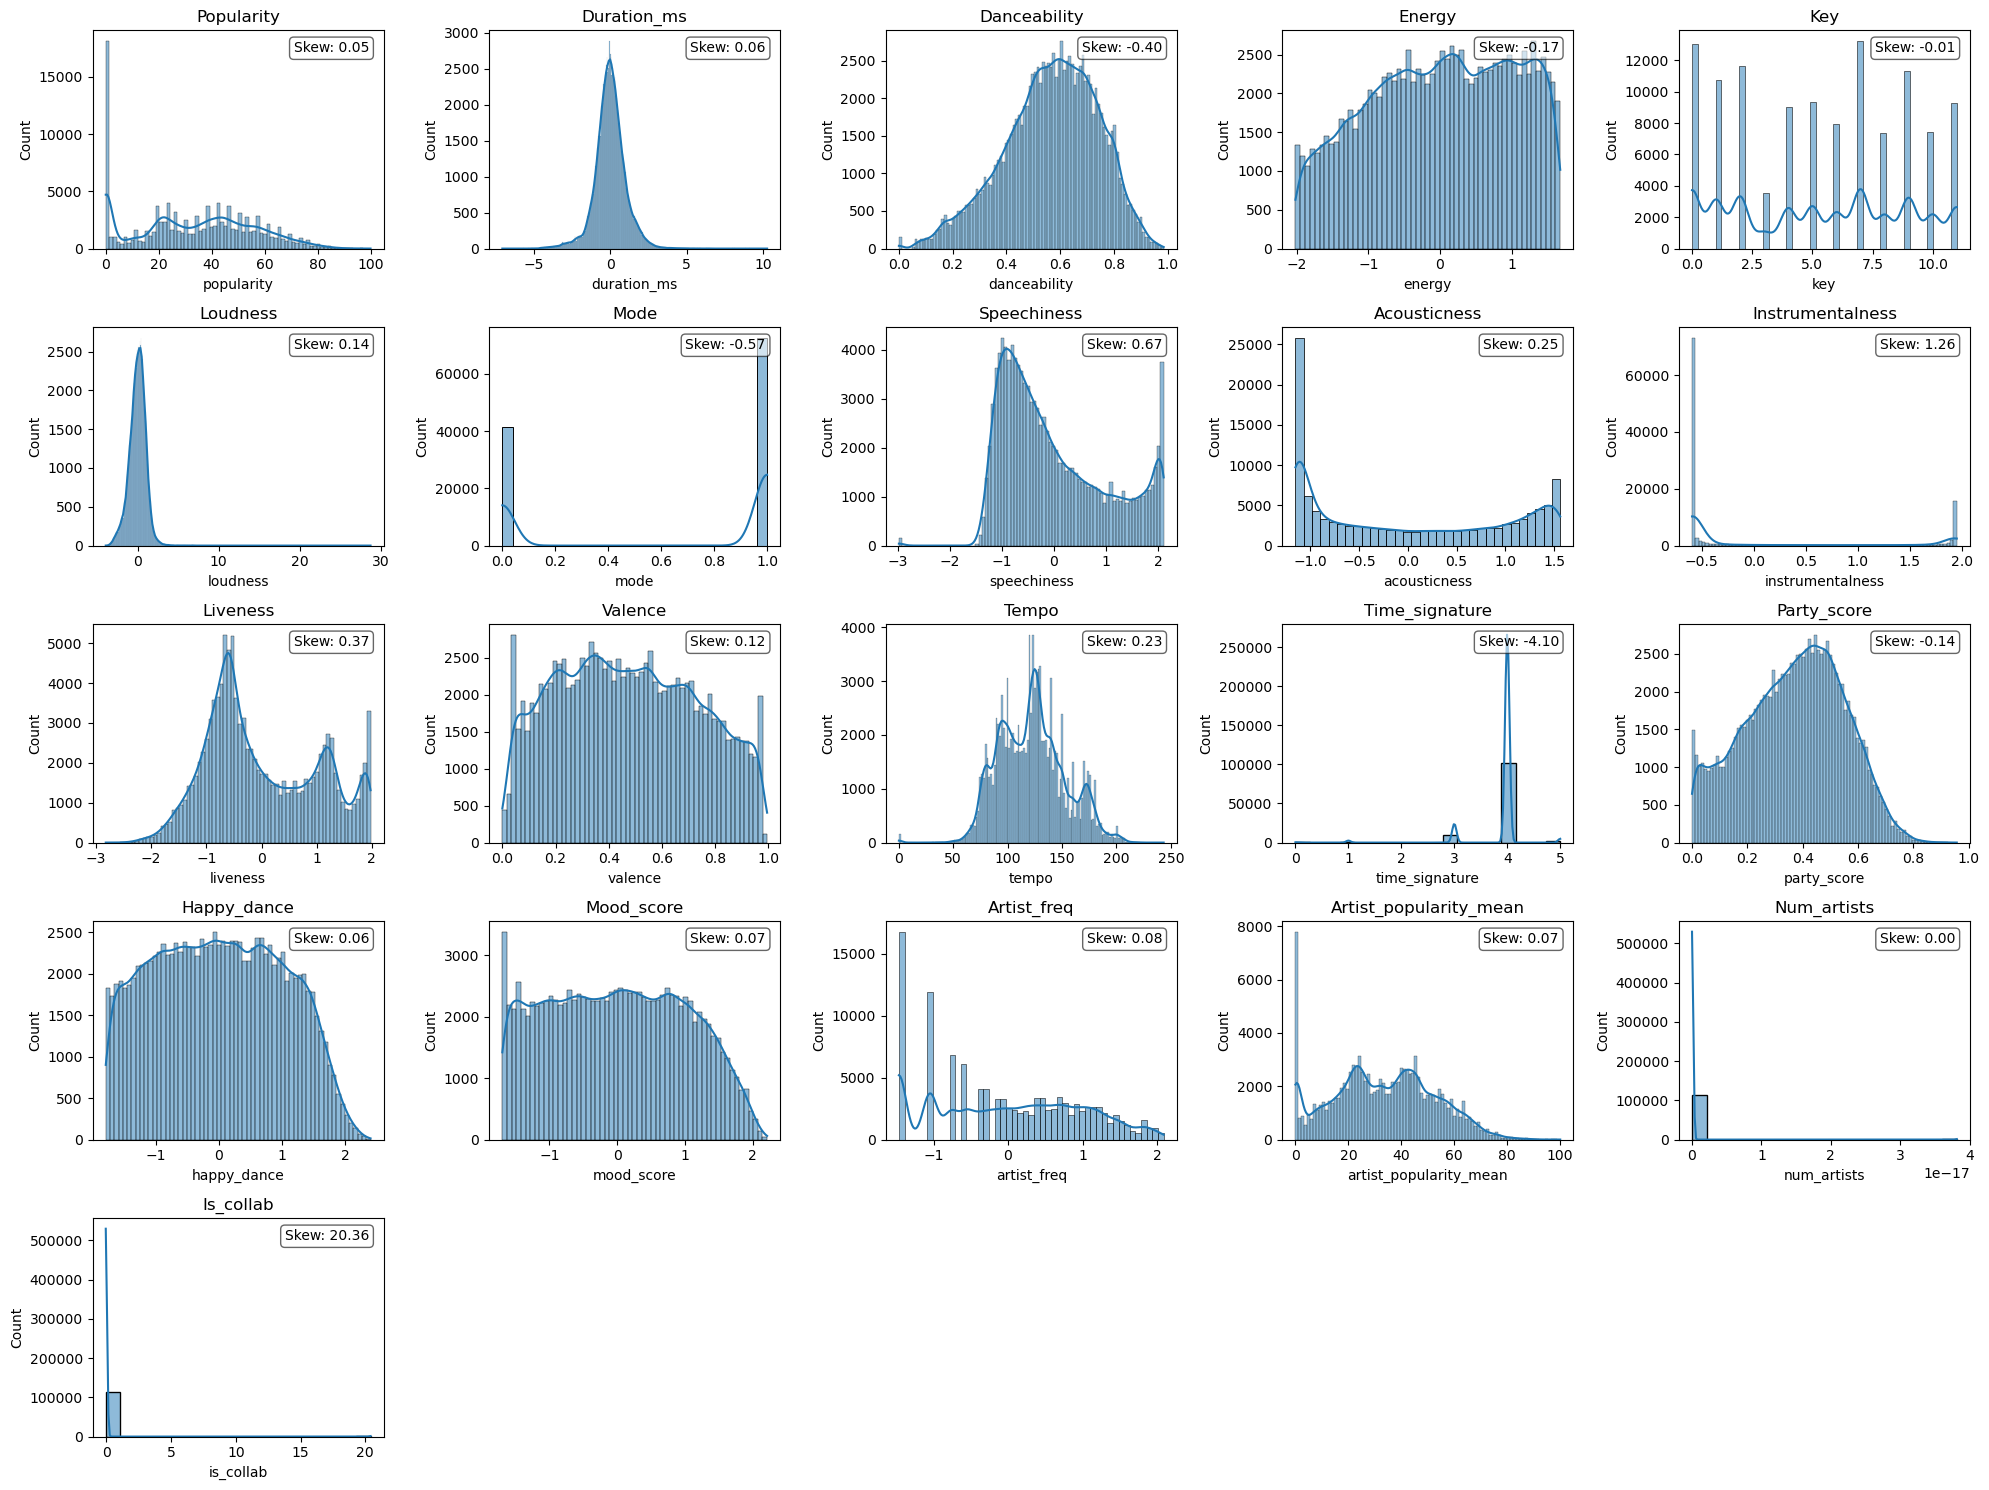

In [9]:
features = df.select_dtypes(include=['int64','float64']).columns.tolist()

plt.figure(figsize=(20, 15))

for i, col in enumerate(features, 1):
    plt.subplot(5, 5, i)
    
    sns.histplot(df[col], kde=True)
    
    skew_val = df[col].skew()
    plt.title(col.capitalize())
    plt.text(0.95, 0.95, f"Skew: {skew_val:.2f}", transform=plt.gca().transAxes, 
             ha='right', va='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

    
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

**6. Checking for multicollinearity**

In [10]:
vif = pd.DataFrame()

vif["Feature"] = numeric_cols
vif["VIF"] = [variance_inflation_factor(df[numeric_cols].values, i) for i in range(df[numeric_cols].shape[1])]

print(vif)

                   Feature            VIF
0               popularity      12.063372
1              duration_ms       1.117406
2             danceability     149.734038
3                   energy      12.760941
4                      key       3.274593
5                 loudness       2.816737
6                     mode       2.890553
7              speechiness       1.266655
8             acousticness       2.149111
9         instrumentalness       1.375549
10                liveness       1.101121
11                 valence      66.015003
12                   tempo      19.929723
13          time_signature      79.015884
14             party_score     100.709716
15             happy_dance      20.883484
16              mood_score      26.331414
17             artist_freq       1.072072
18  artist_popularity_mean      15.349118
19             num_artists  203220.052038
20               is_collab       1.001986


Here only columns - "dancebility" and "party_score" have high VIF value. So removing any one of them could be helpful. Let us drop dancebility.<br>
So now we will drop few of the features to reduce the multicollinearity<br>
Also, there is visible high collinearity in num_artists. This is due to the fact that it is derived from artists. Hence we can drop the column "artists".

In [11]:
df.drop(columns=['danceability', 'artists', 'album_name'], inplace=True)

**7. Outlier Detection**

In [12]:
numeric_cols = df.select_dtypes(include='number').columns

outlier_summary = []

for co in numeric_cols:
    
    Q1 = df[co].quantile(0.25)
    Q3 = df[co].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[co] < lower_bound) | (df[co] > upper_bound)).sum()
    percentage_outliers = (outliers / len(df)) * 100
    outlier_summary.append({
        "Feature": co,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Percentage_Outliers": percentage_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(by="Percentage_Outliers", ascending=False, inplace=True)
outlier_df.head(30)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Percentage_Outliers
8,instrumentalness,-1.772311,1.370220,23107,20.269476
16,is_instrumental,0.000000,0.000000,18850,16.535233
12,time_signature,4.000000,4.000000,12157,10.664129
1,duration_ms,-2.142631,2.145382,5202,4.563198
4,loudness,-2.452260,2.508113,2519,2.209669
11,tempo,37.939750,201.349750,617,0.541233
20,is_collab,-0.048995,-0.048995,273,0.239476
19,num_artists,0.000000,0.000000,273,0.239476
18,artist_popularity_mean,-21.488971,87.893382,50,0.043860
13,party_score,-0.155978,0.896656,9,0.007895


Only time signature and instrumentalness have outliers.<br>
This is due to the fact that<br>
* Instrumentalness: most of the songs do not have only instrumental music i.e they have vocals too
* Time_signature: most of the songs fulfill all the 4 parts. <br>
Hence there is no need to perform any type of outlier analysis

**9. Encoding**

In [13]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

popularity: 101 unique values
duration_ms: 50696 unique values
explicit: 2 unique values
energy: 2083 unique values
key: 12 unique values
loudness: 19480 unique values
mode: 2 unique values
speechiness: 1489 unique values
acousticness: 5061 unique values
instrumentalness: 5346 unique values
liveness: 1722 unique values
valence: 1790 unique values
tempo: 45652 unique values
time_signature: 5 unique values
track_genre: 114 unique values
party_score: 66465 unique values
happy_dance: 65410 unique values
mood_score: 67640 unique values
is_instrumental: 2 unique values
artist_freq: 128 unique values
artist_popularity_mean: 2759 unique values
num_artists: 2 unique values
is_collab: 2 unique values


In [14]:
df['track_genre'] = df['track_genre'].str.split(',')

mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(mlb.fit_transform(df['track_genre']), columns=mlb.classes_, index=df.index)

df = pd.concat([df, genre_encoded], axis=1)

In [15]:
df.drop(columns=['track_genre'], inplace=True)

In [16]:
df['explicit'] = df['explicit'].astype(int)

**10. Scaling**

In [17]:
scaler = StandardScaler()
cols_to_scale = ['energy','loudness','speechiness','acousticness', 'instrumentalness','liveness',
                 'tempo','duration_ms', 'party_score','happy_dance','mood_score','artist_popularity_mean']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [18]:
pd.set_option('display.max_columns', None)
df.sample(10)

,popularity,duration_ms,explicit,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,party_score,happy_dance,mood_score,is_instrumental,artist_freq,artist_popularity_mean,num_artists,is_collab,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,breakbeat,british,cantopop,chicago-house,children,chill,classical,club,comedy,country,dance,dancehall,death-metal,deep-house,detroit-techno,disco,disney,drum-and-bass,dub,dubstep,edm,electro,electronic,emo,folk,forro,french,funk,garage,german,gospel,goth,grindcore,groove,grunge,guitar,happy,hard-rock,hardcore,hardstyle,heavy-metal,hip-hop,honky-tonk,house,idm,indian,indie,indie-pop,industrial,iranian,j-dance,j-idol,j-pop,j-rock,jazz,k-pop,kids,latin,latino,malay,mandopop,metal,metalcore,minimal-techno,mpb,new-age,opera,pagode,party,piano,pop,pop-film,power-pop,progressive-house,psych-rock,punk,punk-rock,r-n-b,reggae,reggaeton,rock,rock-n-roll,rockabilly,romance,sad,salsa,samba,sertanejo,show-tunes,singer-songwriter,ska,sleep,songwriter,soul,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
109792,25,1.466419,0,1.195235,4,-0.846511,0,-0.521758,-1.135220,1.940471,1.734077,0.8330,0.061488,4,1.790886,1.518699,1.703850,1,0.398515,-0.183589,0.0,-0.048995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8146,0,1.366461,0,-0.889175,0,-0.191819,1,0.597650,1.012472,-0.593862,-0.529754,0.6620,0.024161,4,-0.420597,0.846412,0.014700,0,0.820520,-0.725137,0.0,-0.048995,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7706,22,-0.085912,0,-1.386621,10,-0.222207,1,-0.951633,1.322769,-0.593862,-1.091826,0.3830,-0.929366,4,-1.189065,-0.249970,-0.985474,0,-0.398287,-0.536225,0.0,-0.048995,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
42554,13,-2.599492,0,1.617103,11,0.730071,1,1.817842,-1.152051,1.947436,0.948092,0.0372,1.278541,4,-1.336658,-1.744544,-1.437266,1,-0.264053,-1.033756,0.0,-0.048995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9560,45,0.838638,0,1.239511,9,0.742261,1,1.802541,-0.149782,-0.593782,1.858878,0.5000,-0.036416,4,0.889517,0.131912,0.733170,0,0.629813,0.316686,0.0,-0.048995,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
98922,20,-0.089300,0,-0.427427,3,-0.683216,1,2.101224,1.133005,-0.593862,1.521312,0.5800,0.587104,4,-0.128419,0.462603,0.187173,0,-1.464482,-0.693340,0.0,-0.048995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18424,23,-0.884471,0,0.800696,8,0.263236,1,1.969864,0.569599,-0.593862,-0.642801,0.5260,-1.071737,4,1.440542,0.636010,0.659201,0,-0.561680,-0.549318,0.0,-0.048995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
81087,72,0.740454,0,0.648355,8,0.716569,1,-0.132171,-0.244401,-0.593862,0.757025,0.7580,1.26599

**10. Converting the Preprocessed dataset to a csv file**

In [20]:
df.to_csv("processed_spotify_dataset.csv", index=False)